# Explore Data and Labels (Principle: state changes)

**Exercise:** 
1. Identify which numeric label corresponds to baseline, stress, and amusement for this subject (check the dataset’s label map provided with your copy).
2. Create boolean masks like mask_baseline, mask_stress, etc., for use below.

In [1]:
import os
import pickle

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
def load_wesad_subject(pkl_path: str):
    """Return dict with 'signal', 'label', plus any metadata present."""
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')  # WESAD often needs latin1
    # Normalize a few expected top-level keys if available
    out = {'raw': data}
    # Try common patterns
    for k in ['signal', 'signals', 'data']:
        if k in data:
            out['signal'] = data[k]
            break
    if 'label' in data:
        out['label'] = data['label']
    elif 'labels' in data:
        out['label'] = data['labels']
    return out

def summarize_structure(s):
    print("Top-level keys:", list(s['raw'].keys()))
    sig = s.get('signal', {})
    print("Signal namespaces:", list(sig.keys()))
    for ns, v in sig.items():
        if isinstance(v, dict):
            print(f"  [{ns}] channels:", list(v.keys()))
            for ch, arr in v.items():
                try:
                    print(f"    - {ch}: shape={np.array(arr).shape}, dtype={np.array(arr).dtype}")
                except Exception:
                    print(f"    - {ch}: (non-array)")
    if 'label' in s:
        lab = np.array(s['label']).squeeze()
        print("Labels shape:", lab.shape, "| unique:", np.unique(lab))

In [3]:
path_to_pkl = '../../../roeh-health/data/WESAD/per_subject/S7/S7.pkl'
S = load_wesad_subject(path_to_pkl)
summarize_structure(S)

Top-level keys: ['signal', 'label', 'subject']
Signal namespaces: ['chest', 'wrist']
  [chest] channels: ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
    - ACC: shape=(3666600, 3), dtype=float64
    - ECG: shape=(3666600, 1), dtype=float64
    - EMG: shape=(3666600, 1), dtype=float64
    - EDA: shape=(3666600, 1), dtype=float64
    - Temp: shape=(3666600, 1), dtype=float32
    - Resp: shape=(3666600, 1), dtype=float64
  [wrist] channels: ['ACC', 'BVP', 'EDA', 'TEMP']
    - ACC: shape=(167616, 3), dtype=float64
    - BVP: shape=(335232, 1), dtype=float64
    - EDA: shape=(20952, 1), dtype=float64
    - TEMP: shape=(20952, 1), dtype=float64
Labels shape: (3666600,) | unique: [0 1 2 3 4 5 6 7]


Unique label IDs in this subject: [0 1 2 3 4 5 6 7]
Label map (verify with your copy): {0: 'undefined/transient', 1: 'baseline', 2: 'stress', 3: 'amusement', 4: 'meditation'}


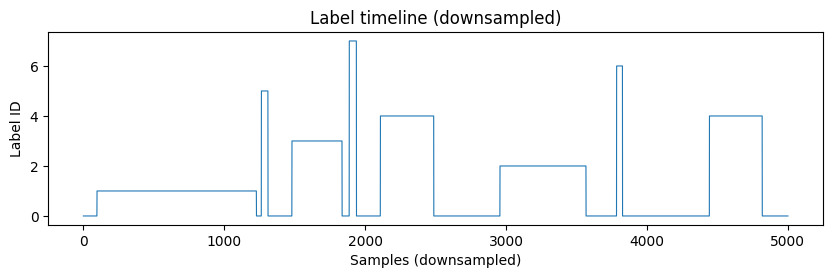

In [4]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

def load_wesad_subject(pkl_path: str):
    """Return dict with 'signal', 'label', plus any metadata present."""
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')  # WESAD often needs latin1
    out = {'raw': data}
    for k in ['signal', 'signals', 'data']:
        if k in data:
            out['signal'] = data[k]
            break
    if 'label' in data:
        out['label'] = data['label']
    elif 'labels' in data:
        out['label'] = data['labels']
    return out

# 1) Identify numeric labels for this subject (use the dataset’s label map)
#    Common WESAD label map (verify with your copy):
wesad_label_map = {
    0: 'undefined/transient',
    1: 'baseline',
    2: 'stress',
    3: 'amusement',
    4: 'meditation'
    # 5/6/7: ignore in WESAD
}

# Load subject
path_to_pkl = '../../../roeh-health/data/WESAD/per_subject/S7/S7.pkl'
S = load_wesad_subject(path_to_pkl)

# Extract labels array
labels = np.array(S.get('label', [])).squeeze()

# Show unique labels present for this subject and how they map
print("Unique label IDs in this subject:", np.unique(labels))
print("Label map (verify with your copy):", wesad_label_map)

# 2) Create boolean masks for baseline, stress, amusement
mask_baseline  = labels == 1
mask_stress    = labels == 2
mask_amusement = labels == 3

# Quick label timeline (downsampled for speed)
if labels.size > 0:
    step = max(1, labels.size // 5000)
    plt.figure(figsize=(10, 2.5))
    plt.plot(labels[::step], lw=0.8)
    plt.title("Label timeline (downsampled)")
    plt.xlabel("Samples (downsampled)")
    plt.ylabel("Label ID")
    plt.show()

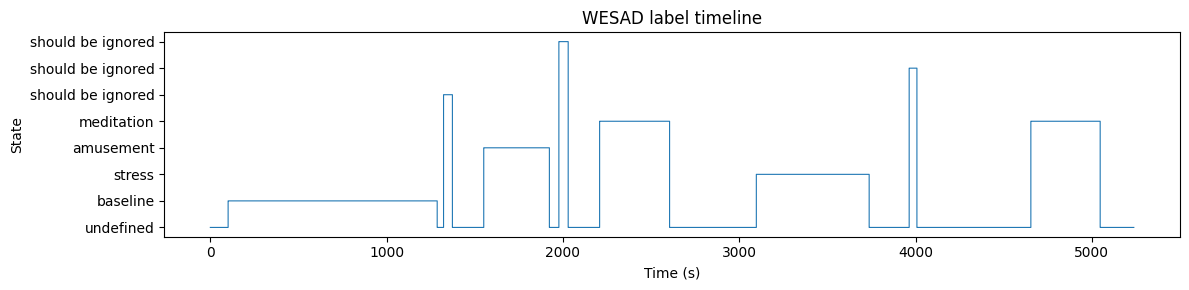

In [5]:
# Plot labels on a time axis (labels sampled at 700 Hz in WESAD)
fs = 700
labels = np.array(S.get('label', [])).squeeze()
label_names = {0: 'undefined', 1: 'baseline', 2: 'stress', 3: 'amusement', 4: 'meditation', 5: 'should be ignored', 6: 'should be ignored', 7: 'should be ignored'}

if labels.size > 0:
    t = np.arange(labels.size) / fs
    step = max(1, labels.size // 10000)

    plt.figure(figsize=(12, 3))
    plt.step(t[::step], labels[::step], where='post', lw=0.8, color='tab:blue')
    uniq = np.unique(labels)
    plt.yticks(uniq, [label_names.get(int(i), str(int(i))) for i in uniq])
    plt.title("WESAD label timeline")
    plt.xlabel("Time (s)")
    plt.ylabel("State")
    plt.tight_layout()
    plt.show()

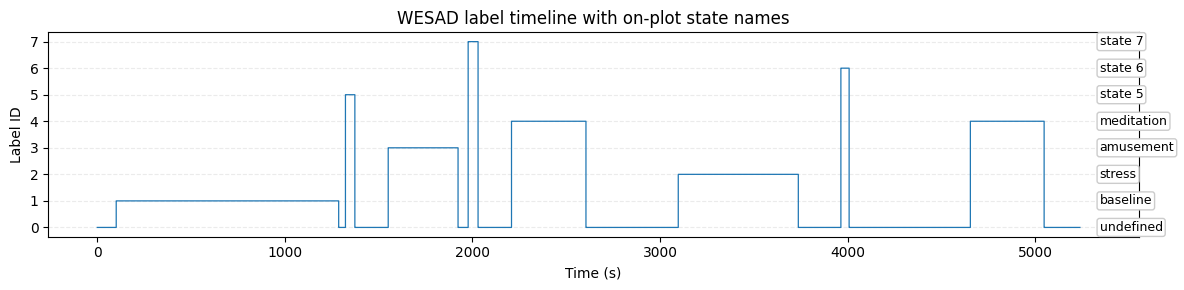

In [6]:
# Plot numeric labels on y-axis and write text labels inside the plot at each y-level
fs = 700
labels = np.array(S.get('label', [])).squeeze()
label_names = {0: 'undefined', 1: 'baseline', 2: 'stress', 3: 'amusement', 4: 'meditation'}

if labels.size > 0:
    t = np.arange(labels.size) / fs
    step = max(1, labels.size // 10000)

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.step(t[::step], labels[::step], where='post', lw=0.9, color='tab:blue')

    uniq = np.sort(np.unique(labels).astype(int))
    ax.set_yticks(uniq)  # keep numbers on y-axis
    ax.set_title("WESAD label timeline with on-plot state names")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Label ID")
    ax.grid(axis='y', alpha=0.25, linestyle='--')

    # make room on the right for text labels
    x0, x1 = ax.get_xlim()
    pad = 0.06 * (t[-1] - t[0] if t.size else 1.0)
    ax.set_xlim(x0, t[-1] + pad)

    # place text labels at each y-value
    x_text = t[-1] + 0.02 * (t[-1] - t[0] if t.size else 1.0)
    for y in uniq:
        name = label_names.get(int(y), f"state {int(y)}")
        ax.text(x_text, y, f"{name}", va='center', ha='left',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.8'),
                clip_on=False)

    plt.tight_layout()
    plt.show()

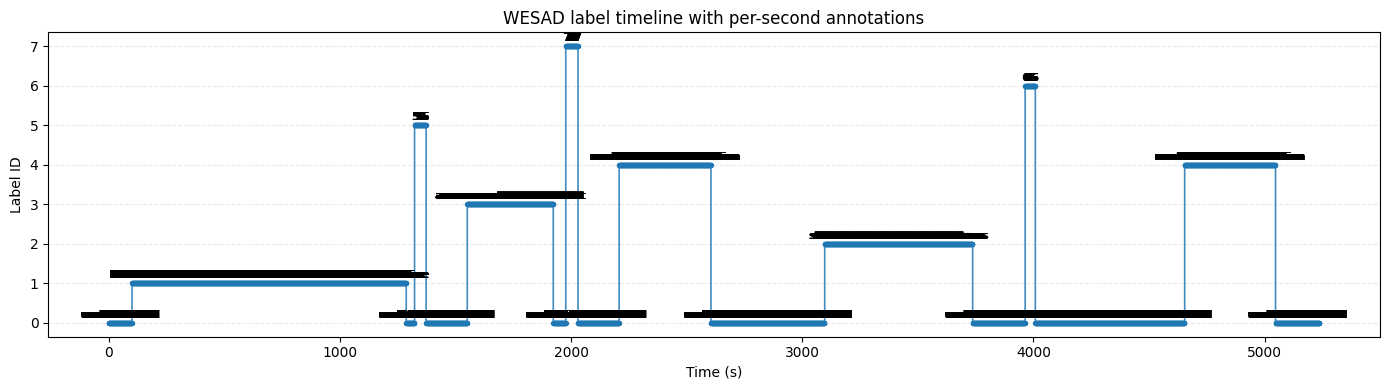

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# assumes S already loaded; labels sampled at 700 Hz
fs = 700
labels = np.array(S.get('label', [])).squeeze().astype(int)

label_names = {0: 'undefined', 1: 'baseline', 2: 'stress', 3: 'amusement', 4: 'meditation'}

# per-second label via majority vote (mode) within each 1-second bin
n = labels.size
n_sec = int(np.ceil(n / fs))
sec_ids = np.empty(n_sec, dtype=int)

for s in range(n_sec):
    start = s * fs
    stop = min((s + 1) * fs, n)
    chunk = labels[start:stop]
    if chunk.size == 0:
        sec_ids[s] = -1
        continue
    # mode via bincount (works for non-negative integer labels)
    counts = np.bincount(chunk)
    sec_ids[s] = counts.argmax()

t_sec = np.arange(n_sec, dtype=float)  # 0,1,2,...

# plot numeric labels and annotate each second with its name
fig, ax = plt.subplots(figsize=(14, 4))
ax.step(t_sec, sec_ids, where='post', lw=1.2, color='tab:blue', alpha=0.85, label='per-second label (mode)')

uniq = np.unique(sec_ids[sec_ids >= 0])
ax.set_yticks(uniq)
ax.set_ylabel("Label ID")
ax.set_xlabel("Time (s)")
ax.set_title("WESAD label timeline with per-second annotations")

# scatter to show the per-second samples
ax.scatter(t_sec, sec_ids, s=8, color='tab:blue', zorder=3)

# annotate each second at its (x, y) with the human-readable label
y_offset = 0.08  # small vertical offset to reduce overlap with points
for x, y in zip(t_sec, sec_ids):
    name = label_names.get(int(y), str(int(y)))
    ax.text(x, y + y_offset, name, ha='center', va='bottom', fontsize=8, rotation=0)

ax.grid(axis='y', alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()

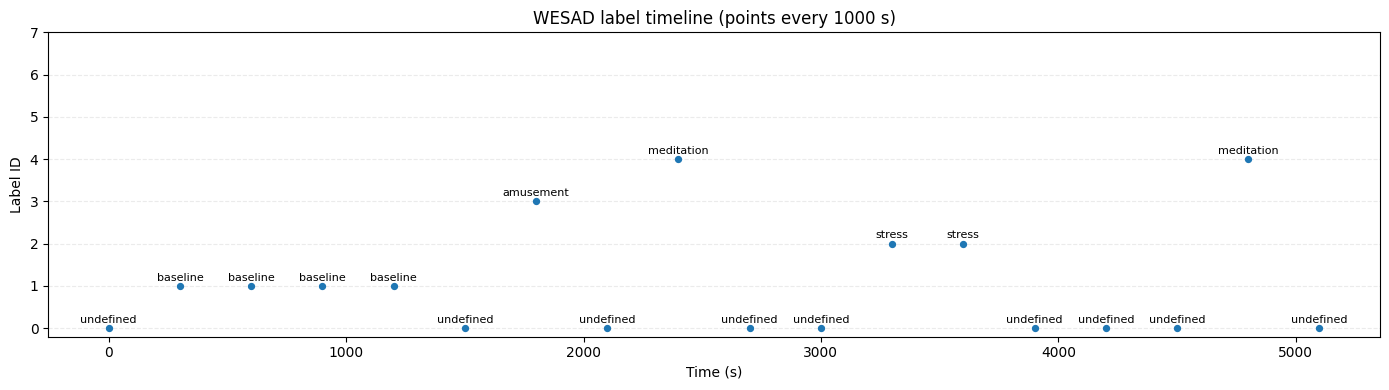

In [8]:
# show only points (and labels) every 1000 seconds
step_seconds = 300
idx = np.arange(0, len(sec_ids), step_seconds)
t_plot = t_sec[idx]
y_plot = sec_ids[idx]

# optional: drop invalid labels (e.g., -1) from plot/annotations
valid = y_plot >= 0
t_plot = t_plot[valid]
y_plot = y_plot[valid]

fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(t_plot, y_plot, s=18, color='tab:blue', zorder=3)

# keep numeric IDs on y-axis
uniq = np.unique(sec_ids[sec_ids >= 0])
ax.set_yticks(uniq)
ax.set_ylabel("Label ID")
ax.set_xlabel("Time (s)")
ax.set_title("WESAD label timeline (points every 1000 s)")

# annotate each shown point with its label name
for x, y in zip(t_plot, y_plot):
    name = label_names.get(int(y), str(int(y)))
    ax.text(x, y + 0.08, name, ha='center', va='bottom', fontsize=8)

ax.grid(axis='y', alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()

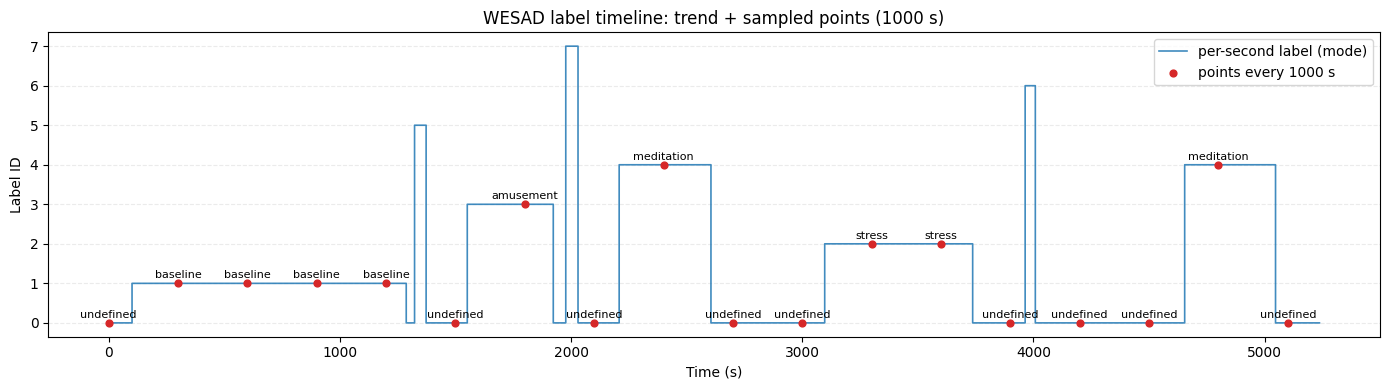

In [9]:
# trend line + points every 1000 seconds
step_seconds = 300
idx = np.arange(0, len(sec_ids), step_seconds)
t_plot = t_sec[idx]
y_plot = sec_ids[idx]

# drop invalid labels (e.g., -1) for plotting/annotations
valid = y_plot >= 0
t_plot = t_plot[valid]
y_plot = y_plot[valid]

fig, ax = plt.subplots(figsize=(14, 4))
# trend line (per-second labels)
ax.step(t_sec, sec_ids, where='post', lw=1.2, color='tab:blue', alpha=0.85, label='per-second label (mode)')
# sampled points every 1000 s
ax.scatter(t_plot, y_plot, s=24, color='tab:red', zorder=3, label='points every 1000 s')

# annotate sampled points with label names
for x, y in zip(t_plot, y_plot):
    ax.text(x, y + 0.08, label_names.get(int(y), str(int(y))), ha='center', va='bottom', fontsize=8)

# keep numeric IDs on y-axis
uniq = np.unique(sec_ids[sec_ids >= 0])
ax.set_yticks(uniq)
ax.set_ylabel("Label ID")
ax.set_xlabel("Time (s)")
ax.set_title("WESAD label timeline: trend + sampled points (1000 s)")
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()